<a href="https://colab.research.google.com/github/Kennethdotse/ayaresa_ai/blob/main/Fine_tuning_MedGemma_for_ayaresa_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Installing Python Packages

In [3]:
! pip install --upgrade --quiet transformers bitsandbytes datasets evaluate peft trl scikit-learn

## Loading and Processing the Dataset

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os
data = '/content/drive/MyDrive/data'
for file in os.listdir(data):
  print(file)


README
mdb001.pgm
Licence.txt
mdb007.pgm
mdb005.pgm
mdb006.pgm
mdb009.pgm
mdb010.pgm
mdb002.pgm
mdb004.pgm
mdb008.pgm
mdb003.pgm
mdb012.pgm
mdb011.pgm
mdb017.pgm
mdb014.pgm
mdb013.pgm
mdb016.pgm
mdb015.pgm
mdb019.pgm
mdb024.pgm
mdb021.pgm
mdb018.pgm
mdb020.pgm
mdb025.pgm
mdb022.pgm
mdb027.pgm
mdb026.pgm
mdb023.pgm
mdb039.pgm
mdb034.pgm
mdb031.pgm
mdb033.pgm
mdb029.pgm
mdb032.pgm
mdb035.pgm
mdb036.pgm
mdb030.pgm
mdb028.pgm
mdb038.pgm
mdb037.pgm
mdb044.pgm
mdb046.pgm
mdb049.pgm
mdb051.pgm
mdb048.pgm
mdb045.pgm
mdb050.pgm
mdb042.pgm
mdb040.pgm
mdb043.pgm
mdb041.pgm
mdb047.pgm
mdb058.pgm
mdb052.pgm
mdb057.pgm
mdb059.pgm
mdb060.pgm
mdb053.pgm
mdb055.pgm
mdb056.pgm
mdb054.pgm
mdb061.pgm
mdb062.pgm
mdb064.pgm
mdb063.pgm
mdb074.pgm
mdb075.pgm
mdb068.pgm
mdb070.pgm
mdb071.pgm
mdb065.pgm
mdb066.pgm
mdb069.pgm
mdb067.pgm
mdb072.pgm
mdb073.pgm
mdb078.pgm
mdb080.pgm
mdb076.pgm
mdb077.pgm
mdb079.pgm
mdb081.pgm
mdb082.pgm
mdb086.pgm
mdb090.pgm
mdb085.pgm
mdb089.pgm
mdb092.pgm
mdb091.pgm
mdb087.pgm
md

In [23]:
import json
import re

IMAGE_DIR = "/content/drive/MyDrive/data/"   # Your image folder
OUTPUT_JSONL = "/content/drive/MyDrive/data/medgemma.jsonl"
RAW_METADATA_FILE = "/content/drive/MyDrive/data/Info.txt"  # save your raw text here



TISSURE_MAP = {
    "F": "Fatty",
    "G": "Fatty-glandular",
    "D": "Dense-glandular"
}

ABN_MAP = {
    "CALC": "Calcification",
    "CIRC": "Well-defined (circumscribed) mass",
    "SPIC": "Spiculated mass",
    "MISC": "Ill-defined mass",
    "ARCH": "Architectural distortion",
    "ASYM": "Asymmetry",
    "NORM": "Normal"
}

SEVERITY_MAP = {
    "B": "Benign",
    "M": "Malignant",
    None: None
}



pattern = re.compile(
    r"^(mdb\d+)\s+([FGD])\s+(\w+)(?:\s+([BM]))?(?:\s+(\d+)\s+(\d+)\s+(\d+))?"
)

records = []

with open(RAW_METADATA_FILE, "r") as f:
    for line in f:
        line = line.strip()
        if not line.startswith("mdb"):
            continue

        match = pattern.match(line)
        if not match:
            continue

        image_id, tissue_c, abn_c, severity_c, x, y, radius = match.groups()

        rec = {
            "image_id": image_id,
            "image": f"{IMAGE_DIR}{image_id}.pgm",
            "tissue": TISSURE_MAP[tissue_c],
            "abnormality": ABN_MAP[abn_c],
            "severity": SEVERITY_MAP[severity_c],
            "x": int(x) if x else None,
            "y": int(y) if y else None,
            "radius": int(radius) if radius else None
        }

        records.append(rec)



def make_samples(rec):
    tissue = rec["tissue"]
    abn = rec["abnormality"]
    sev = rec["severity"]
    img = rec["image_id"]
    x, y, r = rec["x"], rec["y"], rec["radius"]

    if abn == "Normal":
        return [
            (
                "<image>\nDescribe any abnormalities visible in this mammogram.",
                f"No abnormality is annotated in image {img}. "
                f"The breast tissue is classified as {tissue}. "
                f"This mammogram is labelled as normal for training purposes only."
            ),
            (
                "<image>\nWhat breast findings are present?",
                f"Image {img} shows no calcifications, masses, distortions, or asymmetries. "
                f"The tissue type is {tissue}. This is a normal case."
            ),
            (
                "<image>\nProvide a summary of the findings in this mammogram.",
                f"No suspicious findings are recorded in image {img}. "
                f"This example represents a normal mammogram."
            ),
        ]


    if (x is None or y is None or r is None) and abn == "Calcification":
        return [
            (
                "<image>\nDescribe the abnormalities in this mammogram.",
                f"Image {img} contains {sev.lower() if sev else ''} calcifications "
                f"that are distributed widely throughout the breast. "
                f"Specific coordinates are not provided. Tissue type: {tissue}."
            ),
            (
                "<image>\nWhat type of abnormality is present?",
                f"The mammogram contains calcifications labelled as {sev}. "
                f"The distribution is diffuse, and no central point is annotated."
            ),
            (
                "<image>\nSummarize the pathology in this mammogram.",
                f"This image includes widely distributed calcifications. "
                f"Severity: {sev}. Tissue type: {tissue}."
            )
        ]

    sev_text = sev.lower() if sev else "unknown severity"

    return [
        (
            "<image>\nDescribe the abnormalities in this mammogram.",
            f"This mammogram contains a {sev_text} {abn.lower()}. "
            f"The annotated center is at coordinates ({x}, {y}) with an estimated "
            f"radius of {r} pixels. The breast tissue type is {tissue}."
        ),
        (
            "<image>\nWhat findings can you identify in this mammogram?",
            f"Image {img} shows a {sev_text} {abn.lower()} located at ({x}, {y}) "
            f"with a radius of {r} pixels. Tissue composition: {tissue}."
        ),
        (
            "<image>\nProvide a summary of the lesion.",
            f"The image contains a {sev_text} {abn.lower()}. "
            f"Coordinates: ({x}, {y}). Approximate radius: {r} pixels. "
            f"Tissue type: {tissue}."
        ),
    ]


output = []

for rec in records:
    samples = make_samples(rec)
    for idx, (user_text, assistant_text) in enumerate(samples):
        entry = {
            "id": f"{rec['image_id']}_{idx+1}",
            "image": rec["image"],
            "conversations": [
                {"role": "user", "content": user_text},
                {"role": "assistant", "content": assistant_text}
            ]
        }
        output.append(entry)



with open(OUTPUT_JSONL, "w") as f:
    for entry in output:
        f.write(json.dumps(entry) + "\n")

print("✅ FIXED: Generated:", OUTPUT_JSONL)
print("✅ Total multimodal samples created:", len(output))

✅ FIXED: Generated: /content/drive/MyDrive/data/medgemma.jsonl
✅ Total multimodal samples created: 990
✅ <image> token added successfully to all user prompts.


In [24]:
from datasets import load_dataset

data_dir = "/content/drive/MyDrive/data/"

# Define proportions for train and validation splits
train_size = 0.8
validation_size = 0.2


data = load_dataset("imagefolder", data_dir=data_dir, split="train")

# Split the dataset into train and validation sets
data = data.train_test_split(
    train_size=train_size,
    test_size=validation_size,
    shuffle=True,
    seed=42,
)

# Rename the 'test' split to 'validation'
data["validation"] = data.pop("test")

# Display dataset details
print(data)


Resolving data files:   0%|          | 0/327 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image'],
        num_rows: 257
    })
    validation: Dataset({
        features: ['image'],
        num_rows: 65
    })
})


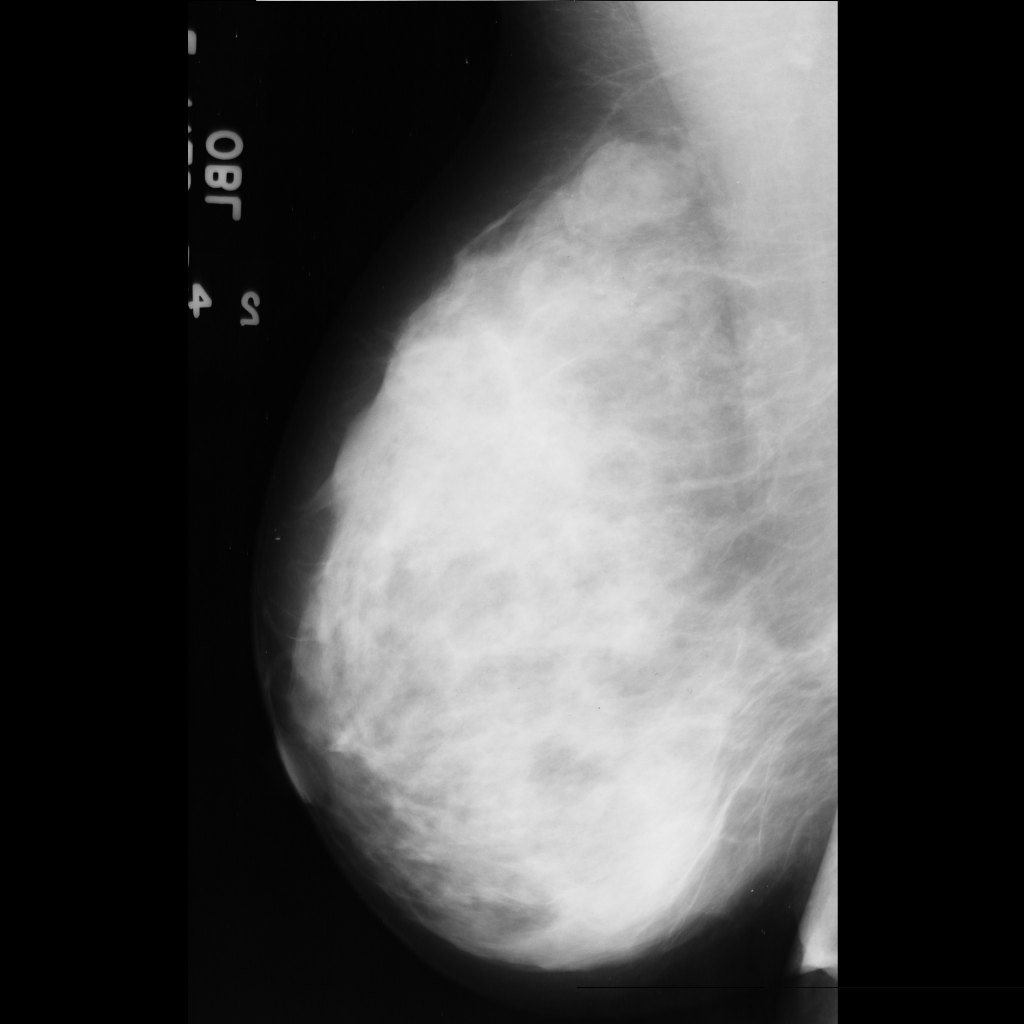

In [25]:
# Display the first image (as a PIL object)
data["train"][45]["image"]


In [26]:
import json

jsonl_data = {}
with open(OUTPUT_JSONL, "r") as f:
    for line in f:
        entry = json.loads(line)
        # Extract image ID from the image path
        image_id = entry["image"].split("/")[-1].split(".")[0]
        jsonl_data[image_id] = entry["conversations"]

In [27]:
def format_data(example: dict[str, any]) -> dict[str, any]:
    # Extract image ID from the image path
    image_id = example["image"].filename.split("/")[-1].split(".")[0]

    # Get the conversations from the jsonl data
    conversations = jsonl_data.get(image_id, [])

    # Check if conversations exist for the image
    if not conversations:
        # Handle cases where the image is not in the jsonl file (e.g., from a different dataset)
        # For now, we'll create a basic prompt without the detailed info
        example["messages"] = [
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {"type": "text", "text": PROMPT},
                ],
            },
            # We don't have the assistant response from the jsonl for this case
        ]
    else:
        example["messages"] = conversations

    return example

# Apply the formatting to the dataset
formatted_data = data.map(format_data)

# Display a sample formatted data point
print(formatted_data["train"][0]["messages"])

Map:   0%|          | 0/257 [00:00<?, ? examples/s]

Map:   0%|          | 0/65 [00:00<?, ? examples/s]

[{'content': '<image>\nProvide a summary of the lesion.', 'role': 'user'}, {'content': 'The image contains a malignant asymmetry. Coordinates: (516, 279). Approximate radius: 98 pixels. Tissue type: Dense-glandular.', 'role': 'assistant'}]


## Loading the Model and Tokenizer

In [28]:
import os
import sys

google_colab = "google.colab" in sys.modules and not os.environ.get("VERTEX_PRODUCT")

if google_colab:
    from google.colab import userdata
    os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
else:
    # Store Hugging Face data under `/content` if running in Colab Enterprise
    if os.environ.get("VERTEX_PRODUCT") == "COLAB_ENTERPRISE":
        os.environ["HF_HOME"] = "/content/hf"
    # Authenticate with Hugging Face
    from huggingface_hub import get_token
    if get_token() is None:
        from huggingface_hub import notebook_login
        notebook_login()

In [29]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig

model_id = "google/medgemma-4b-it"

# Check if GPU supports bfloat16
# if torch.cuda.get_device_capability()[0] < 8:
#     raise ValueError("GPU does not support bfloat16, please use a GPU that supports bfloat16.")

model_kwargs = dict(
    attn_implementation="eager",
    torch_dtype=torch.float16, # Changed to float16 as requested
    device_map="auto",
)

model = AutoModelForImageTextToText.from_pretrained(model_id, **model_kwargs)
processor = AutoProcessor.from_pretrained(model_id)

# Use right padding to avoid issues during training
processor.tokenizer.padding_side = "right"

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

## Setting up the Model

In [30]:
from peft import LoraConfig

peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "down_proj",
        "up_proj",
    ],
    task_type="CAUSAL_LM",
    modules_to_save=["lm_head"],
)


In [40]:
from PIL import Image

def collate_fn(batch):
    # Extract texts + images from dataset entries
    texts = [ex["messages"][0]["content"][1]["text"] for ex in batch] # Access text from the 'messages' key
    images = [ex["image"] for ex in batch]

    # Load images
    pil_images = [Image.open(path).convert("RGB") for path in images]

    # Multimodal input (Gemma-3 requires `prompts=`)
    inputs = processor(
        prompts=texts,
        images=pil_images,
        return_tensors="pt",
        padding=True
    )

    # Labels (assistant responses)
    outputs = processor(
        prompts=[ex["messages"][1]["content"] for ex in batch], # Access assistant response from 'messages' key
        return_tensors="pt",
        padding=True
    )

    inputs["labels"] = outputs["input_ids"]

    return inputs

In [41]:
from trl import SFTConfig

args = SFTConfig(
    output_dir="medgemma-breast-cancer",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=8,
    gradient_checkpointing=True,
    optim="adamw_torch_fused",
    logging_steps=0.1,
    save_strategy="epoch",
    eval_strategy="steps",
    eval_steps=0.1,
    learning_rate=2e-4,
    bf16=True,
    max_grad_norm=0.3,
    warmup_ratio=0.03,
    lr_scheduler_type="linear",
    push_to_hub=True,
    report_to="none",
    gradient_checkpointing_kwargs={"use_reentrant": False},
    dataset_kwargs={"skip_prepare_dataset": True},
    remove_unused_columns = False,
    label_names=["labels"],
)

In [42]:
from trl import SFTTrainer

trainer = SFTTrainer(
    model=model,
    args=args,
    train_dataset=formatted_data["train"],
    eval_dataset=formatted_data["validation"].shuffle().select(range(50)),
    peft_config=peft_config,
    processing_class=processor,
    data_collator=collate_fn,
)

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:73: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:196: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
The model is already on multiple devices. Skipping the move to device specified in `args`.


## Model Training

In [43]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Exception in thread Thread-13 (_loader_worker):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/torch_xla/distributed/parallel_loader.py", line 165, in _loader_worker
    _, data = next(data_iter)
              ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/accelerate/data_loader.py", line 567, in __iter__
    current_batch = next(dataloader_iter)
                    ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 734, in __next__
    data = self._next_data()
      

Step,Training Loss,Validation Loss


TrainOutput(global_step=0, training_loss=0.0, metrics={'train_runtime': 85.8045, 'train_samples_per_second': 3.077, 'train_steps_per_second': 0.058, 'total_flos': 0, 'train_loss': 0.0, 'epoch': 0})

In [18]:
trainer.save_model()

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...-cancer/training_args.bin: 100%|##########| 6.29kB / 6.29kB            

  ...st-cancer/tokenizer.model: 100%|##########| 4.69MB / 4.69MB            

  ...adapter_model.safetensors:   5%|4         | 67.0MB / 1.41GB            

  ...ast-cancer/tokenizer.json: 100%|##########| 33.4MB / 33.4MB            

No files have been modified since last commit. Skipping to prevent empty commit.


## Model Evaluation

In [ ]:
del model
del trainer
torch.cuda.empty_cache()

### Setting up for model testing